## Tank Drain Solver
Simulates the flow of fluid in and out of a tank initially filled with two-phase nitrous oxide. 

In [ ]:
# Instal CoolProp package, only required once
# %pip install pyfluids

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import CoolProp.CoolProp as CP

In [3]:
def psi_to_Pa(psi):
    return psi * 6894.76

def Pa_to_psi(Pa):
    return Pa / 6894.76

def f_to_k(f):
    return (f - 32) * 5/9 + 273.15

def k_to_f(k):
    return (k - 273.15) * 9/5 + 32

In [4]:
# Simulation Parameters
time_step = 0.5 # s
time_gain = 1 # time step growth factor
max_dt = 10 # maximum time step
min_dt = 0.1 # minimum time step
temp_gain = 0.0001 # temperature growth factor
pressure_threshold = 0.1 # Pa # Maximum pressure differential at convergence
energy_threshold = 0.05 # Maximum energy differential at temperature convergence
mass_threshold = 0.01 # kg # Maximum mass for small time steps near convergence
simulation_timeout = 5000 # s
moving_average_window = 10
pressure_change_threshold = 1e-3 # Pa # Change in moving average for convergence
temperature_change_threshold = 1e-3 # K # Change in moving average for convergence
mass_change_threshold = 1e-3 # kg # Change in moving average for convergence

# Tank Properties
outlet_cv = 0.00717
outer_diameter = 3.5 * 0.0254 # m
wall_thickness = 0.125 * 0.0254 # m
max_height = 11.503 * 1.1 * 0.0254 # m
outlet_height = 11.503 * 0.0254 # m
# total_mass = 1.0923 # kg
fuel_mass = 0.390 # kg
piston_mass = 0.147
inlet_cv = 0.05
supply_pressure = psi_to_Pa(898.6)

# Heat Transfer Properties
air_convection = 10
nitrous_convection = 1000
thermal_conductivity = 150

# Environment Properties
ambient_pressure = 101325 # Pa
ambient_temp = f_to_k(85) # K

# Initial Conditions
temp = f_to_k(85) # K
tank_height = max_height
liquid_height = 0.05*outlet_height
vapor_height = tank_height - liquid_height

In [5]:
# Initialize fluid properties
time = 0
converged = False
cross_section_area = np.pi * (outer_diameter/2 - wall_thickness)**2
tank_volume = cross_section_area * tank_height
liquid_density = CP.PropsSI('D', 'T', temp, 'Q', 0, 'NitrousOxide')
vapor_density = CP.PropsSI('D', 'T', temp, 'Q', 1, 'NitrousOxide')
liquid_energy = CP.PropsSI('U', 'T', temp, 'Q', 0, 'NitrousOxide')
vapor_energy = CP.PropsSI('U', 'T', temp, 'Q', 1, 'NitrousOxide')
tank_pressure = CP.PropsSI('P', 'T', temp, 'Q', 0, 'NitrousOxide')
# liquid_mass = (tank_volume - total_mass / vapor_density) * (liquid_density * vapor_density / (vapor_density - liquid_density))
# vapor_mass = total_mass - liquid_mass
# print(liquid_mass)
# print(vapor_mass)
liquid_mass = liquid_height * cross_section_area * liquid_density
vapor_mass = vapor_height * cross_section_area * vapor_density
total_mass = liquid_mass + vapor_mass
energy = liquid_mass * liquid_energy + vapor_mass * vapor_energy

# Calculate heat transfer constants
outer_surface_area = 2 * np.pi * outer_diameter/2 * tank_height
inner_surface_area = 2 * np.pi * (outer_diameter/2 - wall_thickness) * tank_height
mean_surface_area = (outer_surface_area - inner_surface_area) / np.log(outer_surface_area / inner_surface_area)
thermal_conductance = 1/(1/(air_convection*outer_surface_area) + wall_thickness/(thermal_conductivity*mean_surface_area) + 1/(nitrous_convection*inner_surface_area))

# Prepare data logging
data = []
data.append({"Time": time,"Pressure": tank_pressure,"Temperature": temp,"Mass": total_mass,"Liquid": liquid_mass, "Energy": energy})
data_smoothed = []

# print(tank_volume)
# print(liquid_mass)
# print(vapor_mass)

In [6]:
while (time < simulation_timeout):# and (tank_pressure - ambient_pressure > pressure_threshold) and total_mass > 0):
    # Calculate incoming and escaped mass
    liquid_height = liquid_mass / (cross_section_area * liquid_density)
    drain_vapor_phase = liquid_height < outlet_height
    
    fill_density = liquid_density
    drain_density = vapor_density if drain_vapor_phase else liquid_density
    
    mass_flow_fill = fill_density * inlet_cv * abs(Pa_to_psi(supply_pressure - tank_pressure) * 1000 / fill_density) ** 0.5 * 0.00379 / 60
    mass_flow_drain = drain_density * outlet_cv * abs(Pa_to_psi(tank_pressure - ambient_pressure) * 1000 / drain_density) ** 0.5 * 0.00379 / 60
    
    # Reverse flow if pressure gradient flips
    if supply_pressure < tank_pressure: 
        mass_flow_fill *= -1
    if tank_pressure < ambient_pressure:
        mass_flow_drain *= -1

    dm_liquid_in = (mass_flow_fill) * time_step
    dm_vapor_in = 0
    dm_liquid_out = -(mass_flow_drain if not drain_vapor_phase else 0) * time_step
    dm_vapor_out = -(mass_flow_drain if drain_vapor_phase else 0) * time_step
    mass_flow = mass_flow_fill - mass_flow_drain
    dm = max(mass_flow * time_step, total_mass * -1)
    total_mass += dm
    # print("Mass flow:", mass_flow, "dm:", dm)

    # Calculate change in energy
    target_energy = energy
    heat_transfer = thermal_conductance * (ambient_temp - temp) * time_step
    target_energy += heat_transfer
    prev_temp = temp

    # Liquid and vapor
    if (liquid_mass > 0 or mass_flow_fill > 0):
        h_liquid = CP.PropsSI('H', 'T', temp, 'Q', 0, 'NitrousOxide')
        h_vapor = CP.PropsSI('H', 'T', temp, 'Q', 1, 'NitrousOxide')
        
        # Inlet fluid enthalpy at supply pressure (saturated liquid)
        h_inlet = CP.PropsSI('H', 'P', supply_pressure, 'Q', 0, 'NitrousOxide')
        
        # Energy balance: incoming fluid + outgoing fluid
        inlet_energy = dm_liquid_in * h_inlet if mass_flow_fill > 0 else 0
        outlet_energy = dm_liquid_out * h_liquid + dm_vapor_out * h_vapor
        target_energy += inlet_energy + outlet_energy
    
        # Find temperature and corresponding vapor quality with target energy
        last_temp = temp
        last_energy = energy
        for i in range(1000):
            error = target_energy - energy
            if abs(error) <= energy_threshold:
                # print("converged")
                # print("Target: ", target_energy)
                # print("energy: ", energy)
                # print("temp: ", temp)
                # print("i: ", i)
                break

            # Newton's method
            # Estimate dU_dT
            dT = 0.01
            rho_l_plus = CP.PropsSI('D', 'T', temp + dT, 'Q', 0, 'NitrousOxide')
            rho_v_plus = CP.PropsSI('D', 'T', temp + dT, 'Q', 1, 'NitrousOxide')
            drho_l_dT = (rho_l_plus - liquid_density) / dT
            drho_v_dT = (rho_v_plus - vapor_density) / dT
            # m_l = (V - m/rho_v) * rho_l*rho_v / (rho_v - rho_l)
            # Let A = V - m/rho_v, B = rho_l*rho_v/(rho_v - rho_l)
            A = tank_volume - total_mass / vapor_density
            B = liquid_density * vapor_density / (vapor_density - liquid_density)
            
            dA_dT = total_mass / vapor_density**2 * drho_v_dT
            dB_dT = ((drho_l_dT * vapor_density + liquid_density * drho_v_dT) * (vapor_density - liquid_density)
                     - liquid_density * vapor_density * (drho_v_dT - drho_l_dT)
                   ) / (vapor_density - liquid_density)**2
            
            dm_l_dT = dA_dT * B + A * dB_dT
            dm_v_dT = -dm_l_dT
            u_l = CP.PropsSI('U', 'T', temp, 'Q', 0, 'NitrousOxide')
            u_v = CP.PropsSI('U', 'T', temp, 'Q', 1, 'NitrousOxide')
            cv_l = CP.PropsSI('CVMASS', 'T', temp, 'Q', 0, 'NitrousOxide')
            cv_v = CP.PropsSI('CVMASS', 'T', temp, 'Q', 1, 'NitrousOxide')
            
            dU_dT = (liquid_mass * cv_l 
                   + vapor_mass * cv_v 
                   + (u_v - u_l) * dm_v_dT)
            #slope = -5e2
            slope = dU_dT
            if (energy != last_energy and temp != last_temp):
                slope = (energy - last_energy) / (temp - last_temp)
            last_energy = energy
            last_temp = temp
            temp += error / slope
            temp = min(temp, 309.3)
            temp = max(temp, 0.5)
            
            liquid_density = CP.PropsSI('D', 'T', temp, 'Q', 0, 'NitrousOxide')
            vapor_density = CP.PropsSI('D', 'T', temp, 'Q', 1, 'NitrousOxide')
            liquid_energy = CP.PropsSI('U', 'T', temp, 'Q', 0, 'NitrousOxide')
            vapor_energy = CP.PropsSI('U', 'T', temp, 'Q', 1, 'NitrousOxide')
            
            liquid_mass = (tank_volume - total_mass / vapor_density) * (liquid_density * vapor_density / (vapor_density - liquid_density))
            vapor_mass = total_mass - liquid_mass
            energy = liquid_mass * liquid_energy + vapor_mass * vapor_energy
            
        else:
            print("Warning: energy convergence failed at t=%.2f" % time)
            print("Target: ", target_energy)
            print("energy: ", energy)
            print("temp: ", temp)
            print("time_Step: ", time_step)
            
        energy = target_energy
        # Update pressure at new temperature
        tank_pressure = CP.PropsSI('P', 'T', temp, 'Q', 1, 'NitrousOxide')
        # Transition to vapor-only
        if liquid_mass <= 0:
            print("Liquid evaporated in %.1fs" % time)
            vapor_mass = total_mass
            liquid_mass = 0
            vapor_density = total_mass / tank_volume
            u = energy / total_mass
            
            # At evaporation point, energy is already correctly calculated as internal energy
            # Just recalculate T and P for the pure vapor state
            try:
                temp = CP.PropsSI('T', 'D', vapor_density, 'U', u, 'NitrousOxide')
                tank_pressure = CP.PropsSI('P', 'D', vapor_density, 'U', u, 'NitrousOxide')
            except ValueError:
                print(f"Warning: Invalid state at evaporation point")
                # Keep previous values and let vapor-only section handle it
                pass
            
    # Vapor only 
    else:
        # Stop simulation if tank is essentially empty
        if total_mass < 1e-6:
            print(f"Tank empty (mass={total_mass:.2e}), stopping simulation at t={time:.1f}s")
            break
        
        vapor_mass = total_mass
        liquid_mass = 0
        
        # Simple energy balance for open system (tank losing mass):
        # dE/dt = Q - h_out * dm_out/dt
        # where h_out is specific enthalpy at tank conditions
        
        # Apply heat transfer and mass flow
        vapor_density_old = total_mass / tank_volume
        
        try:
            # Get enthalpy at current state to subtract from exiting mass
            h_vapor_current = CP.PropsSI('H', 'T', temp, 'D', vapor_density_old, 'NitrousOxide')
            
            # Heat transfer
            heat_transfer = thermal_conductance * (ambient_temp - temp) * time_step
            
            # DEBUG: Print energy balance terms for first few vapor iterations
            if time < 87.5 and liquid_mass == 0:
                print(f"DEBUG t={time:.2f}: dm_out={dm_vapor_out:.6f}, h={h_vapor_current:.1f}, E_before={energy:.1f}, Q={heat_transfer:.1f}")
            
            # Energy balance: energy change = heat in + enthalpy of exiting mass
            # (dm_vapor_out is negative when mass exits, so we subtract it as in dE = Q - h*|dm_out|)
            energy = energy + heat_transfer + dm_vapor_out * h_vapor_current
            
            if time < 87.5 and liquid_mass == 0:
                print(f"DEBUG t={time:.2f}: E_after={energy:.1f}, term1={dm_vapor_out * h_vapor_current:.1f}")
            
            # Now find temperature at the new energy state
            u_specific = energy / total_mass
            vapor_density_new = total_mass / tank_volume
            
            # Solve for temperature using internal energy
            temp = CP.PropsSI('T', 'D', vapor_density_new, 'U', u_specific, 'NitrousOxide')
            tank_pressure = CP.PropsSI('P', 'D', vapor_density_new, 'U', u_specific, 'NitrousOxide')
            
        except ValueError as e:
            print(f"Warning: Invalid vapor state at t={time:.2f}, terminating")
            print(f"  Reason: {str(e)}")
            break

    time += time_step
    
    # Increase time step if change is small
    #time_step = min(max_dt, time_gain/(abs(prev_temp-temp)+1e-6))
    # Decrease time step near runout
    if liquid_mass > 0 and liquid_mass < mass_threshold:
        time_step = min(time_step, min_dt)

    # Validate state before appending
    is_valid = True
    if tank_pressure < 0 or tank_pressure > 2000 * 6894.76:  # Unrealistic pressure
        print(f"Warning: Invalid pressure {Pa_to_psi(tank_pressure):.1f} psi at t={time:.1f}s, ending simulation")
        is_valid = False
    if temp < 0 or temp > 350:  # Temperature outside reasonable range (K)
        print(f"Warning: Invalid temperature {k_to_f(temp):.1f}°F at t={time:.1f}s, ending simulation")
        is_valid = False
    if total_mass < 0 or total_mass > 100:  # Mass outside reasonable range
        print(f"Warning: Invalid mass {total_mass:.4f} kg at t={time:.1f}s, ending simulation")
        is_valid = False
    
    if not is_valid:
        break

    data.append({"Time": time,"Pressure": tank_pressure,"Temperature": temp,"Mass": total_mass,"Liquid": liquid_mass, "Energy": energy})
    # print("t:", temp, "\tp:", tank_pressure, "\tm:", total_mass)

    # Check for convergence
    avg_pressure = sum(item["Pressure"] for item in data[-10:]) / len(data[-10:])
    avg_temperature = sum(item["Temperature"] for item in data[-10:]) / len(data[-10:])
    avg_mass = sum(item["Mass"] for item in data[-10:]) / len(data[-10:])
    data_smoothed.append({"Time": time,"Pressure": avg_pressure,"Temperature": avg_temperature,"Mass": avg_mass})

    if len(data_smoothed) >= 10 and abs(avg_pressure - data_smoothed[-2]["Pressure"]) < pressure_change_threshold and abs(avg_temperature - data_smoothed[-2]["Temperature"]) < temperature_change_threshold and abs(avg_mass - data_smoothed[-2]["Mass"]) < mass_change_threshold:
        if not converged:
            converged = True
            time_step = min_dt
            print(f"Convergence reached at t={time:.1f}s")
            simulation_timeout = time + 100
        #break

print("Simulation completed in %.1fs" % time)
print("Temperature:", k_to_f(avg_temperature))
print("Pressure:", Pa_to_psi(avg_pressure))
print("Total mass:", avg_mass)

Convergence reached at t=188.5s
Simulation completed in 288.5s
Temperature: 82.93976072913043
Pressure: 881.5016934308113
Total mass: 1.1424126684964544


In [93]:
df = pd.DataFrame(data)
df['Pressure'] = df['Pressure'] / 6894.76
df['Temperature'] = k_to_f(df['Temperature'])

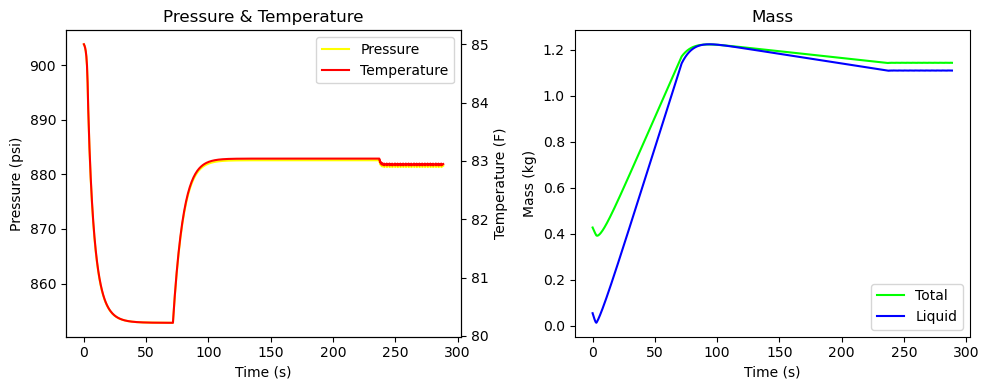

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

lineP = ax1.plot(df.Time, df.Pressure, label='Pressure', color='yellow', linestyle='-')
axtwin = ax1.twinx()
lineT = axtwin.plot(df.Time, df.Temperature, label='Temperature', color='red', linestyle='-')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Pressure (psi)')
axtwin.set_ylabel('Temperature (F)')
ax1.set_title('Pressure & Temperature')
lines = lineP + lineT
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

ax2.plot(df.Time, df.Mass, label='Total', color='lime', linestyle='-')
ax2.plot(df.Time, df.Liquid, label='Liquid', color='blue', linestyle='-')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Mass (kg)')
ax2.set_title('Mass')
ax2.legend()

# ax3.plot(df.Time, df.Energy, label='Energy', color='purple', linestyle='-')
# ax3.set_xlabel('Time (s)')
# ax3.set_ylabel('Energy (J)')
# ax3.set_title('Energy')
# ax3.legend()

plt.tight_layout()
#plt.savefig('mass_runout.png')
plt.show()

In [19]:
# Debug: check initial and final conditions
print("Initial conditions:")
print(f"  Tank pressure: {Pa_to_psi(psi_to_Pa(898.6)):.1f} psi")
print(f"  Temperature: {k_to_f(f_to_k(85)):.1f} °F")
print(f"  Total mass: {data[0]['Mass']:.4f} kg")
print(f"  Liquid mass: {data[0]['Liquid']:.4f} kg")
print(f"  Outlet Cv: {outlet_cv}")
print()
print("First few data points:")
for i in range(min(5, len(data))):
    print(f"  t={data[i]['Time']:.1f}s: P={Pa_to_psi(data[i]['Pressure']):.1f}psi, T={k_to_f(data[i]['Temperature']):.1f}°F, m={data[i]['Mass']:.4f}kg")
print()
print("Last few data points:")
for i in range(max(0, len(data)-5), len(data)):
    print(f"  t={data[i]['Time']:.1f}s: P={Pa_to_psi(data[i]['Pressure']):.1f}psi, T={k_to_f(data[i]['Temperature']):.1f}°F, m={data[i]['Mass']:.4f}kg")

Initial conditions:
  Tank pressure: 898.6 psi
  Temperature: 85.0 °F
  Total mass: 1.1226 kg
  Liquid mass: 1.0872 kg
  Outlet Cv: 0.00717

First few data points:
  t=0.0s: P=898.6psi, T=85.0°F, m=1.1226kg
  t=1.0s: P=899.4psi, T=84.6°F, m=1.1114kg
  t=2.0s: P=891.6psi, T=83.9°F, m=1.1050kg
  t=3.0s: P=883.8psi, T=83.2°F, m=1.0987kg
  t=4.0s: P=876.1psi, T=82.4°F, m=1.0925kg

Last few data points:
  t=4999.6s: P=14.7psi, T=85.0°F, m=0.0031kg
  t=4999.7s: P=14.7psi, T=85.0°F, m=0.0031kg
  t=4999.8s: P=14.7psi, T=85.0°F, m=0.0031kg
  t=4999.9s: P=14.7psi, T=85.0°F, m=0.0031kg
  t=5000.0s: P=14.7psi, T=85.0°F, m=0.0031kg


In [6]:
# Check data around evaporation point
evap_idx = None
for i, d in enumerate(data):
    if d['Time'] >= 87 and d['Liquid'] <= 0:
        if evap_idx is None:
            evap_idx = i
            break

if evap_idx:
    print(f"Evaporation occurs around index {evap_idx} (time ~87s)")
    print(f"\nData around evaporation:")
    start = max(0, evap_idx - 3)
    end = min(len(data), evap_idx + 10)
    for i in range(start, end):
        d = data[i]
        P_psi = Pa_to_psi(d['Pressure'])
        T_F = k_to_f(d['Temperature'])
        print(f"  i={i}: t={d['Time']:6.1f}s, P={P_psi:7.1f}psi, T={T_F:7.1f}°F, m={d['Mass']:7.4f}kg, L={d['Liquid']:7.4f}kg")

Evaporation occurs around index 89 (time ~87s)

Data around evaporation:
  i=86: t=  86.0s, P=  571.2psi, T=   48.8°F, m= 0.2032kg, L= 0.0109kg
  i=87: t=  87.0s, P=  567.6psi, T=   48.3°F, m= 0.1933kg, L= 0.0013kg
  i=88: t=  87.1s, P=  567.2psi, T=   48.3°F, m= 0.1924kg, L= 0.0004kg
  i=89: t=  87.2s, P=  568.2psi, T=   49.1°F, m= 0.1914kg, L= 0.0000kg
  i=90: t=  87.3s, P=  574.6psi, T=   52.4°F, m= 0.1904kg, L= 0.0000kg
  i=91: t=  87.4s, P=  581.1psi, T=   55.7°F, m= 0.1894kg, L= 0.0000kg
  i=92: t=  87.5s, P=  587.7psi, T=   59.2°F, m= 0.1884kg, L= 0.0000kg
  i=93: t=  87.6s, P=  594.3psi, T=   62.8°F, m= 0.1874kg, L= 0.0000kg
  i=94: t=  87.7s, P=  601.0psi, T=   66.5°F, m= 0.1864kg, L= 0.0000kg
  i=95: t=  87.8s, P=  607.7psi, T=   70.3°F, m= 0.1854kg, L= 0.0000kg
  i=96: t=  87.9s, P=  614.4psi, T=   74.2°F, m= 0.1843kg, L= 0.0000kg
  i=97: t=  88.0s, P=  621.2psi, T=   78.2°F, m= 0.1833kg, L= 0.0000kg
  i=98: t=  88.1s, P=  628.0psi, T=   82.3°F, m= 0.1823kg, L= 0.0000kg
